# 02 — Hawkes processes, and a volatility predicted from the flow alone

Market orders arrive in bursts.  A Hawkes process is the smallest model that
says why: every event raises the intensity of the next,

$$\lambda_i(t) = \mu_i + \sum_j \int_0^t \varphi_{ij}(t-s)\,dN_j(s),$$

and the spectral radius of $\int\varphi$ is the average number of events each
event triggers -- the *endogeneity ratio*.

The chapter has three parts.  The estimator is checked against a process whose
kernel we chose.  It is then applied to the buy/sell flow of the panel, where a
goodness-of-fit test that can actually reject the model does reject it.  And
the fitted flow makes a prediction about the *price*: the variance per unit
time of the signed trade count, at every scale, in closed form.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")

84 symbol-days, 12 symbols, 7 dates


## Ground truth: recover a kernel we injected

The kernel bank has fixed decay rates and free non-negative amplitudes, which
makes the log-likelihood concave -- the estimate is a global maximum, not
wherever an optimiser happened to stop.

In [2]:
from hfx.hawkes.simulate import simulate_exp
from hfx.hawkes.fit import fit_exp_bank, log_grid
from hfx.hawkes.gof import ks_exponential, qq_points, rescaled_residuals

rng = np.random.default_rng(7)
mu, alpha, beta, T = np.array([0.5]), np.array([[0.8]]), np.array([[2.0]]), 30_000.0
times, marks = simulate_exp(mu, alpha, beta, T, rng)
exact = fit_exp_bank(times, marks, betas=np.array([2.0]), T=T, d=1)
coarse = fit_exp_bank(times, marks, betas=log_grid(0.1, 100, 6), T=T, d=1)
print(f"true branching ratio 0.400   fitted {exact.branching_ratio:.3f} (beta known)"
      f"   {coarse.branching_ratio:.3f} (beta on a six-point grid)")
assert abs(exact.branching_ratio - 0.4) < 0.03

true branching ratio 0.400   fitted 0.389 (beta known)   0.405 (beta on a six-point grid)


## The test that can say no

Under the fitted model the compensator-rescaled inter-arrival times are i.i.d.
$\mathrm{Exp}(1)$ -- exactly, not approximately.  So a Kolmogorov-Smirnov test
against $\mathrm{Exp}(1)$ is a test of the model rather than a picture of a fit
next to the data it was fitted to.

simulated data, true model: mean residual 1.000, KS p = 0.740


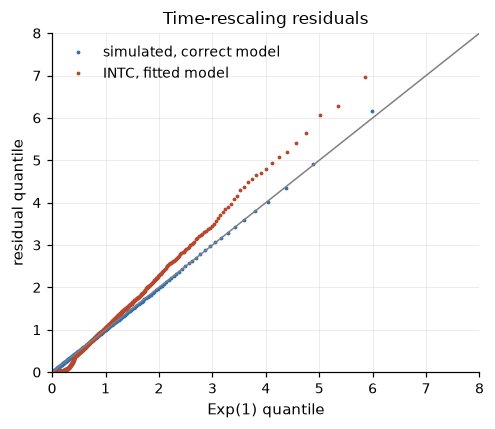

In [3]:
res_true = rescaled_residuals(times, marks, exact)[0]
_, p_true = ks_exponential(res_true)
print(f"simulated data, true model: mean residual {res_true.mean():.3f}, KS p = {p_true:.3f}")

fig, ax = subplots(figsize=(4.6, 4.0))
x, y = qq_points(res_true)
ax.plot(x, y, ".", ms=3, label="simulated, correct model")
sym = "INTC"
tq = curve(C, sym, DAY, "hawkes_residual_qq").ravel()
from scipy import stats
probs = np.linspace(0.5 / tq.size, 1 - 0.5 / tq.size, tq.size)
ax.plot(stats.expon.ppf(probs), np.sort(tq), ".", ms=3, label=f"{sym}, fitted model")
lim = [0, 8]; ax.plot(lim, lim, color="0.5", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Exp(1) quantile"); ax.set_ylabel("residual quantile")
ax.set_title("Time-rescaling residuals"); ax.legend()
plt.tight_layout()

## The panel

Two numbers per symbol-day: the endogeneity ratio, and the *net* excitation
$\delta = s - c$ between self- and cross-excitation.  A buy making the next buy
more likely is order splitting; a buy making a sell more likely is the other
side reacting.  Which one dominates decides whether the signed order flow
trends or mean-reverts.

In [4]:
h = P.groupby("symbol").agg(price=("price", "mean"), spread=("median_spread_ticks", "mean"),
                            n=("hawkes_branching", "mean"), n_sd=("hawkes_branching", "std"),
                            self_=("hawkes_self", "mean"), cross=("hawkes_cross", "mean"),
                            delta=("hawkes_delta", "mean"),
                            n_single=("hawkes_branching_single", "mean"),
                            ks_p=("hawkes_ks_p", "max")).sort_values("price")
print(h.round(4).to_string())
print(f"\nbranching ratio across the panel: {h.n.min():.2f} to {h.n.max():.2f}")
print(f"largest KS p-value anywhere in the panel: {h.ks_p.max():.2e}")
assert (h.delta > 0).all(), "self-excitation should dominate: order flow persists"

            price   spread       n    n_sd   self_   cross   delta  n_single  ks_p
symbol                                                                            
SIRI       6.3802   1.0000  0.8250  0.0565  0.7908  0.0342  0.7566    0.5531   0.0
MU        46.4253   1.0000  0.8455  0.0451  0.6954  0.1501  0.5453    0.7264   0.0
CSCO      49.2140   1.0000  0.7981  0.0457  0.6903  0.1078  0.5825    0.6762   0.0
INTC      54.4818   1.0000  0.8185  0.0453  0.6873  0.1312  0.5560    0.7167   0.0
MSFT     139.1194   1.1429  0.8574  0.0746  0.7139  0.1435  0.5704    0.7446   0.0
AAPL     231.7255   2.2857  0.8567  0.0213  0.7488  0.1080  0.6408    0.7801   0.0
NFLX     324.2518  12.1429  0.8607  0.0209  0.7605  0.1002  0.6602    0.7712   0.0
TSLA     344.8857  15.5714  0.8993  0.0609  0.7984  0.1010  0.6974    0.8215   0.0
REGN     347.8627  27.0000  0.7252  0.0398  0.6481  0.0771  0.5710    0.6976   0.0
ISRG     545.3376  39.4286  0.7435  0.0878  0.6668  0.0768  0.5900    0.6956   0.0
GOOG

Every fit is rejected, on every symbol, on every day, with p-values
that are numerically zero.  That is the expected outcome and it is worth stating
plainly: a Hawkes process with a handful of exponentials is *not* the law of the
order flow.  What the fit still gives is a well-defined summary of how much of
the flow is triggered by itself, and the sum-of-exponentials bank raises that
estimate over a single exponential -- the single-kernel fit cannot see the slow
part of the excitation and attributes it to the baseline instead.

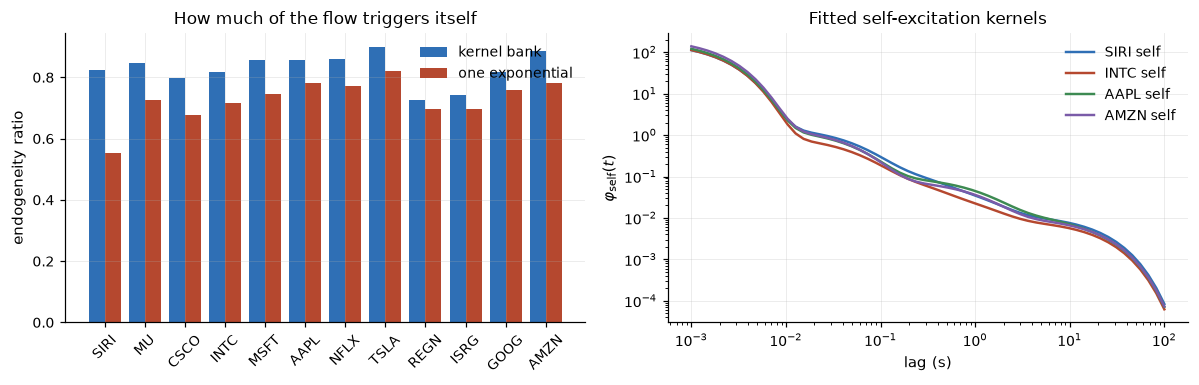

In [5]:
fig, axes = subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(np.arange(len(h)) - 0.2, h.n, width=0.4, label="kernel bank")
axes[0].bar(np.arange(len(h)) + 0.2, h.n_single, width=0.4, label="one exponential")
axes[0].set_xticks(np.arange(len(h))); axes[0].set_xticklabels(h.index, rotation=45)
axes[0].set_ylabel("endogeneity ratio"); axes[0].legend()
axes[0].set_title("How much of the flow triggers itself")
lags = curve(C, "INTC", DAY, "hawkes_kernel_lags")
for sym in ["SIRI", "INTC", "AAPL", "AMZN"]:
    k = curve(C, sym, DAY, "hawkes_kernel")
    axes[1].loglog(lags, k[0, 0], label=f"{sym} self")
axes[1].set_xlabel("lag (s)"); axes[1].set_ylabel(r"$\varphi_{\rm self}(t)$")
axes[1].set_title("Fitted self-excitation kernels"); axes[1].legend()
plt.tight_layout()

## The prediction

For a symmetric buy/sell flow the signed trade count $P_t = N^+_t - N^-_t$ has a
spectrum that collapses to a scalar, and the variance per unit time over a scale
$\tau$ follows in closed form.  Two limits are worth naming:

$$V(0^+) = 2\Lambda, \qquad V(\infty) = \frac{2\Lambda}{(1-(s-c))^2}.$$

With self-excitation dominating, $s>c$, the variance per unit time **rises** with
the scale: persistent flow.  Nothing about prices enters the estimation -- only
the times and signs of the trades -- so comparing the curve with the realised
signature plot of the same day is a genuine out-of-sample check.

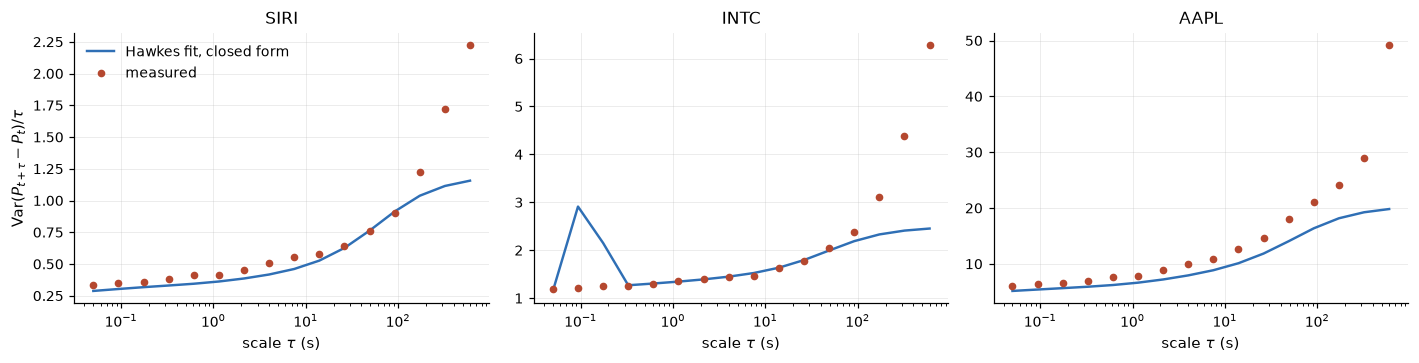

In [6]:
fig, axes = subplots(1, 3, figsize=(13, 3.4))
for ax, sym in zip(axes, ["SIRI", "INTC", "AAPL"]):
    taus = curve(C, sym, DAY, "hawkes_taus")
    model = curve(C, sym, DAY, "hawkes_signature_model")
    emp = curve(C, sym, DAY, "hawkes_signature_empirical")
    ax.semilogx(taus, model, label="Hawkes fit, closed form")
    ax.semilogx(taus, emp, "o", ms=4, label="measured")
    ax.set_title(sym); ax.set_xlabel(r"scale $\tau$ (s)")
axes[0].set_ylabel(r"$\mathrm{Var}(P_{t+\tau}-P_t)/\tau$"); axes[0].legend()
plt.tight_layout()

In [7]:
rows = []
for sym in sorted(P.symbol.unique()):
    taus = curve(C, sym, DAY, "hawkes_taus")
    model = curve(C, sym, DAY, "hawkes_signature_model")
    emp = curve(C, sym, DAY, "hawkes_signature_empirical")
    ok = np.isfinite(emp) & (emp > 0)
    rows.append({"symbol": sym, "median ratio": float(np.median(emp[ok] / model[ok])),
                 "ratio at the short end": float(emp[ok][0] / model[ok][0]),
                 "ratio at the long end": float(emp[ok][-1] / model[ok][-1])})
sig = pd.DataFrame(rows).set_index("symbol")
print(sig.round(3).to_string())
print(f"\nmedian over the panel: {sig['median ratio'].median():.3f}")

        median ratio  ratio at the short end  ratio at the long end
symbol                                                             
AAPL           1.241                   1.165                  2.480
AMZN           1.274                   1.248                  2.304
CSCO           1.246                   1.268                  1.536
GOOG           1.678                   1.609                  2.722
INTC           1.003                   1.041                  2.559
ISRG           1.218                   1.162                  1.887
MSFT           1.282                   1.227                  2.545
MU             1.130                   1.100                  2.604
NFLX           1.041                   1.053                  1.189
REGN           1.182                   1.227                  1.180
SIRI           1.167                   1.173                  1.922
TSLA           1.391                   1.340                  2.422

median over the panel: 1.230


The short end matches by construction -- at $\tau\to0$ the variance rate
is twice the trade intensity, which any fit gets right.  The long end is the
test, and it is where the exponential bank runs out: the measured variance keeps
growing past the scale at which the fitted kernel has decayed.  That is the same
verdict the goodness-of-fit test gave, seen in the price rather than in the
residuals, and it is the standard argument for a power-law kernel.